In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as const
from scipy.special import wofz
from tqdm import tqdm
from rtfunctions import one_full_fs, sc_2nd_order, calc_lambda_full, calc_lambda_monoc
import time
import illuminated_finite_slab as ill

In [2]:
def plot_line_and_composite(lines, slab, S_nu_grid, I_emergent):
    x = slab.x_values
    tau = slab.tau
    B = slab.B
    # ensure per-line normalized profile present
    for line in lines:
        if not hasattr(line, 'phi_x_global'):
            line.compute_phi_x(x)
            if getattr(slab, 'x_weights', None) is None:
                dx = x[1] - x[0]
                slab.x_weights = np.ones_like(x) * dx
            norm = np.sum(line.phi_x * slab.x_weights)
            line.phi_x_global = line.phi_x / norm if norm != 0.0 else line.phi_x.copy()

    # Precompute denom used in composite S
    denom = np.zeros_like(x)
    for line in lines:
        denom += line.k * line.phi_x_global
    denom_safe = np.where(denom == 0.0, 1.0, denom)

    # 1) For each line: emissivity vs x at selected depths, and S_line vs tau with Planck B
    depths_idx = [0, slab.ND // 2, slab.ND - 1]  # top, mid, bottom
    for i, line in enumerate(lines):
        # emissivity spectra at selected depths: eps(x) = k * phi(x) * S_line(depth)
        plt.figure(figsize=(8,5))
        for d in depths_idx:
            emiss = line.k * line.phi_x_global * line.S_line[d]
            plt.plot(x, emiss, label=f'depth idx {d}')
        plt.plot(x, np.mean(B) * np.ones_like(x), ':k', label='Planck B (mean)')
        plt.xlabel('x (Doppler units)')
        plt.ylabel('Emissivity ~ k phi(x) S_line(depth)')
        plt.title(f'Line {i+1} emissivity vs x (selected depths) — center={line.line_center}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'line_{i+1}_emissivity_vs_x.png', dpi=150)
        plt.close()

        # S_line vs tau with Planck B reference
        plt.figure(figsize=(6,5))
        plt.plot(tau, line.S_line, label=f'Line {i+1} S_line')
        # Plot Planck B; if B is depth-dependent plot full curve else mean
        if np.size(B) == slab.ND:
            plt.plot(tau, B, ':k', label='Planck B (depth)')
        else:
            plt.plot(tau, np.mean(B) * np.ones_like(tau), ':k', label='Planck B (mean)')
        plt.xscale('log')
        plt.xlabel('Optical depth (tau)')
        plt.ylabel('Source function')
        plt.title(f'Line {i+1} Source function vs tau')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'line_{i+1}_S_vs_tau.png', dpi=150)
        plt.close()

    # 2) Composite source: S_nu vs x for selected depths, with Planck B
    plt.figure(figsize=(8,5))
    for d in depths_idx:
        plt.plot(x, S_nu_grid[d, :], label=f'Composite S at depth idx {d}')
    plt.plot(x, np.mean(B) * np.ones_like(x), ':k', label='Planck B (mean)')
    plt.xlabel('x (Doppler units)')
    plt.ylabel('Composite source S_nu (depth slice)')
    plt.title('Composite Source Function vs x (selected depths)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('composite_S_vs_x_selected_depths.png', dpi=150)
    plt.close()

    # 3) Composite source vs tau at line centers (for each line choose its center index)
    plt.figure(figsize=(6,5))
    for i, line in enumerate(lines):
        idx = np.argmin(np.abs(x - line.line_center))
        plt.plot(tau, S_nu_grid[:, idx], label=f'Composite S at x~{line.line_center:.2g}')
    if np.size(B) == slab.ND:
        plt.plot(tau, B, ':k', label='Planck B (depth)')
    else:
        plt.plot(tau, np.mean(B) * np.ones_like(tau), ':k', label='Planck B (mean)')
    plt.xscale('log')
    plt.xlabel('Optical depth (tau)')
    plt.ylabel('Composite source at selected x')
    plt.title('Composite S vs tau at line centers')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('composite_S_vs_tau_line_centers.png', dpi=150)
    plt.close()

    # 4) Per-line contribution to composite S for all depths (combined single figure)
    # contribution(depth,x) = (k * phi(x) * S_line(depth)) / denom(x)
    for i, line in enumerate(lines):
        contrib = (line.k * line.phi_x_global[None, :] ) * line.S_line[:, None]
        contrib /= denom_safe[None, :]  # safe division
    # Build per-line contribution arrays (depth x frequency) and plot them ON THE SAME figure
    contribs = []
    for line in lines:
        contrib = (line.k * line.phi_x_global[None, :]) * line.S_line[:, None]
        contrib /= denom_safe[None, :]  # safe division
        contribs.append(contrib)

    # Single combined figure: composite S heatmap + contour overlays of contributions
    plt.figure(figsize=(10, 6))
    im = plt.imshow(S_nu_grid, aspect='auto', origin='lower',
                    extent=[x[0], x[-1], tau[0], tau[-1]], cmap='plasma')
    cbar = plt.colorbar(im, label='Composite S_nu(depth, x)')
    # choose distinct contour colors for up to 6 lines
    palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
    contour_levels = [0.05, 0.1, 0.25, 0.5]  # fractional contribution levels

    # Build explicit legend handles (one per line) to avoid relying on contour internals
    from matplotlib.lines import Line2D
    legend_handles = []
    for idx, contrib in enumerate(contribs):
        color = palette[idx % len(palette)]
        # draw contours; guard against any library differences
        try:
            CS = plt.contour(x, tau, contrib, levels=contour_levels, colors=[color],
                             linewidths=1.0, alpha=0.9)
        except Exception:
            # fallback: draw a thin filled contourf for visibility
            plt.contourf(x, tau, contrib, levels=[0.0] + contour_levels, colors=[color], alpha=0.05)

        # create a proxy artist for legend
        legend_handles.append(Line2D([0], [0], color=color, lw=2, label=f'Line {idx+1} contrib'))

    plt.xlabel('x (Doppler units)')
    plt.ylabel('Optical depth (tau)')
    plt.title('Composite S_nu (heatmap) with line contribution contours')
    plt.gca().set_yscale('linear')
    # add legend for contribution proxies + a proxy for heatmap
    heatmap_proxy = Line2D([0], [0], color='k', lw=2, linestyle='--', label='Composite S (example)')
    all_handles = [heatmap_proxy] + legend_handles
    plt.legend(handles=all_handles, loc='upper right')
    plt.tight_layout()
    plt.savefig('combined_line_contributions_depth_x.png', dpi=150)
    plt.close()

    # 5) Per-line contributions vs x for ALL depths (decimated curves to avoid overplotting)
    plt.figure(figsize=(11,6))
    decim = max(1, int(np.ceil(slab.ND / 60)))  # plot up to ~60 depth curves
    depths_all = np.arange(0, slab.ND, decim)
    for idx, contrib in enumerate(contribs):
        color = palette[idx % len(palette)]
        # plot many depth slices with low alpha
        for d in depths_all:
            plt.plot(x, contrib[d, :], color=color, alpha=0.08, linewidth=1)
        # overlay a thicker mean contribution curve for visibility
        mean_curve = np.mean(contrib[depths_all, :], axis=0)
        plt.plot(x, mean_curve, color=color, lw=1.5, alpha=0.9, label=f'Line @{lines[idx].line_center} contribution (avg depths)')

        # find depth where this line contributes the most (integrated over x with weights)
        if getattr(slab, "x_weights", None) is None:
            dx = x[1] - x[0]
            xw = np.ones_like(x) * dx
        else:
            xw = slab.x_weights
        # total fractional contribution per depth (weighted integral over x)
        total_per_depth = np.sum(contrib * xw[None, :], axis=1)
        depth_max = int(np.argmax(total_per_depth))
        # plot the contribution curve at that depth as a thick line
        plt.plot(x, contrib[depth_max, :], color=color, lw=2.5, alpha=1.0, linestyle = "--",
                 label=f'Line @{lines[idx].line_center} peak depth idx={depth_max}, tau={slab.tau[depth_max]:.2g}')

    # overlay composite S (choose mid depth) as dashed black curve for comparison
    mid = slab.ND // 2
    plt.plot(x, S_nu_grid[mid, :], '--k', lw=2.0, label='Composite S (mid depth)')
    # overlay Planck B reference (mean)
    plt.plot(x, np.mean(B) * np.ones_like(x), ':k', label='Planck B (mean)')
    plt.xlabel('x (Doppler units)')
    plt.ylabel('Per-line contribution to composite S')
    plt.title('Per-line contributions vs x (all depths overlay; avg & mid shown)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('per_line_contributions_all_depths_vs_x.png', dpi=150)
    plt.close()

    print("Saved plots: per-line emissivity, S_vs_tau, composite S vs x/tau, combined contribution heatmap, and per-line contributions (all depths).")

<h2>Playground for 2 components</h2>
<p>Testing out the illuminated finite slab module. So far it works for a single component, but we are now trying to extend it to two components. We want to produce the He I 1083 nm line profile.</p>

In [3]:
# Let's create a slab first
ND = 51
tau_max = 1e3
epsilon = np.ones(ND) * 5e-3
B = np.ones(ND) * 5.0

slab = ill.Slab(ND, tau_max, epsilon, B, H=70000.0)

In [4]:
# Calculate the scattered J
slab.calculate_J_scat()

Converged after 57 iterations.


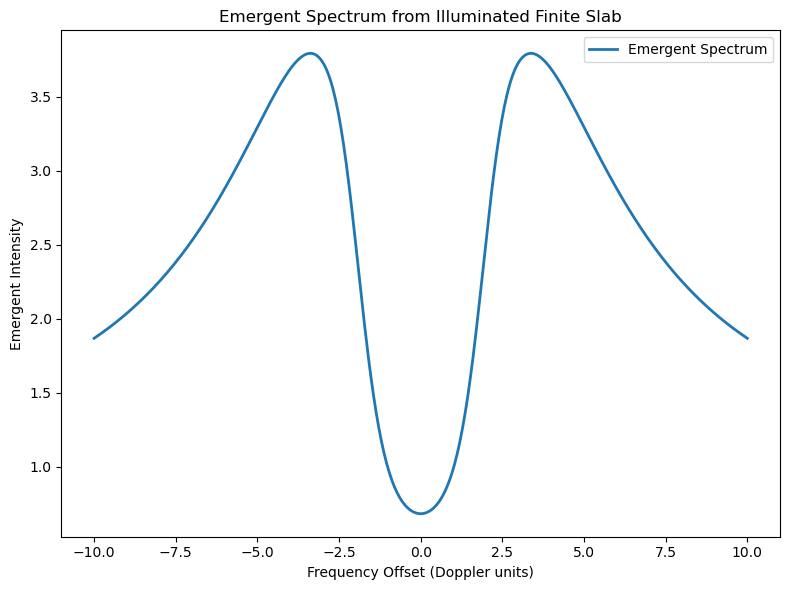

In [5]:
# First, solve for one component
slab.solve_source_function_ALO(max_iter=500, tol=1e-6)
S_alo = slab.S

# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab.a = 0.1 # Set damping parameter
spectrum = slab.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab.solve_source_function()
S_direct = slab.S

# Plot the results
plt.figure(figsize=(8,6))
plt.plot(x_obs, spectrum, linewidth = 2, label="Emergent Spectrum")
plt.xlabel("Frequency Offset (Doppler units)")
plt.ylabel("Emergent Intensity")
plt.title("Emergent Spectrum from Illuminated Finite Slab")
plt.legend()
plt.tight_layout()

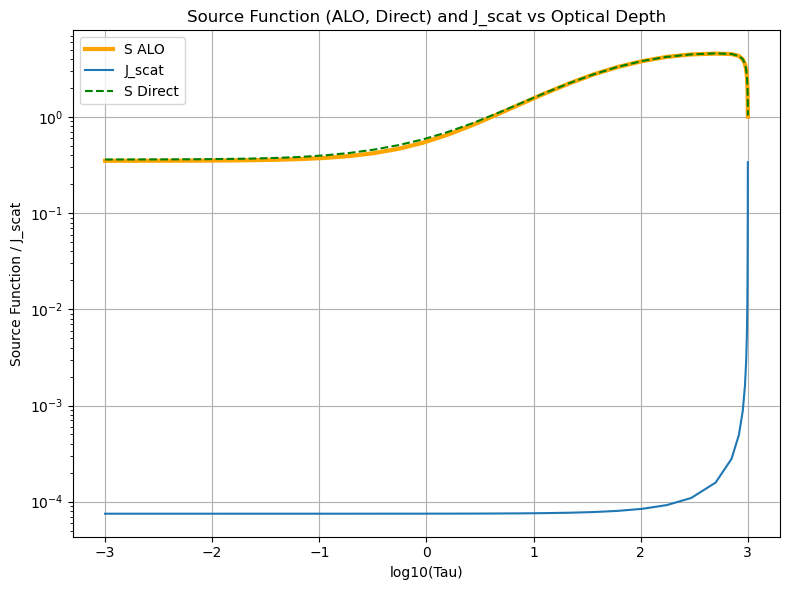

In [6]:
plt.figure(figsize=(8,6))
plt.semilogy(np.log10(slab.tau),S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(np.log10(slab.tau),slab.J_scat, label="J_scat")
plt.semilogy(np.log10(slab.tau),S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("log10(Tau)")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function (ALO, Direct) and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

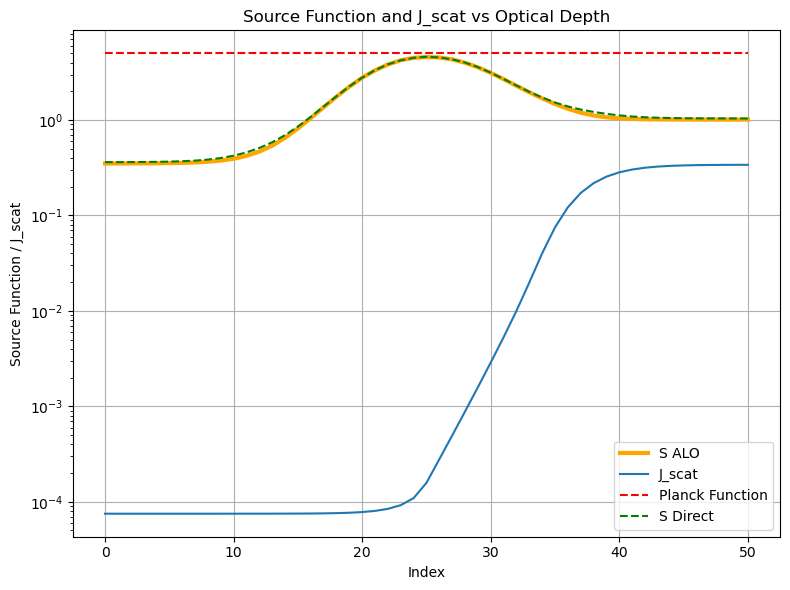

In [7]:
# Other variant where we use the depth index to plot all the variables
plt.figure(figsize=(8,6))
plt.semilogy(S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

<h3>So far, so good...</h3>
<p>This is within the expectacions and in accordance with literature.</p>
<h3>But what about two components?</h3>
<p>The next step is to define two-component profiles in the same slab. The idea is to have two different sets of parameters for the two components, and then combine their contributions to get the final profile.</p>
<p>We will need to define parameters such as optical depth, Doppler width, and source function for each component separately. Then, we can compute the emergent intensity by summing the contributions from both components.</p>
<p>Let's implement this and see how the resulting profile looks compared to the single-component case.</p>

In [8]:
slab2 = ill.Slab(ND, tau_max, epsilon, B, H=10e6) # Note height in m

<p>After some consideration, we have decided to use Lambda iteration instead of ALI for the initial attempt to model two components. This approach will me slightly slower, but it will be easier to write. </p>
<p> Absorption WIP </p>

In [9]:
# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab.a = 0.1 # Set damping parameter
spectrum = slab2.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab2.calculate_J_scat()

slab2.solve_source_function_LI_2comp()
S_LI = slab2.S

In [10]:
print(np.shape(slab2.J_scat))
print(np.shape(slab2.phi))

(51,)
(41,)


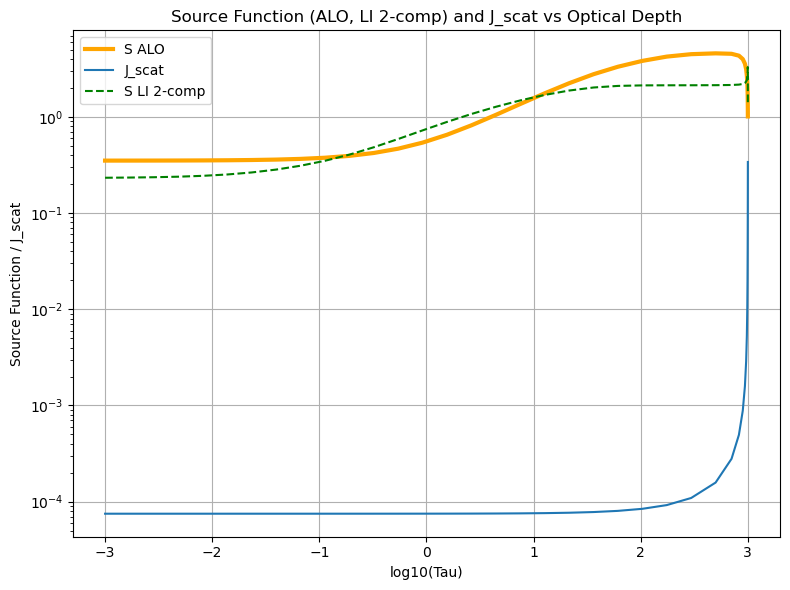

In [11]:
plt.figure(figsize=(8,6))
plt.semilogy(np.log10(slab.tau),S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(np.log10(slab.tau),slab.J_scat, label="J_scat")
plt.semilogy(np.log10(slab.tau),S_LI, linestyle = "--", color = "green", alpha = 1.0, label="S LI 2-comp")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("log10(Tau)")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function (ALO, LI 2-comp) and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

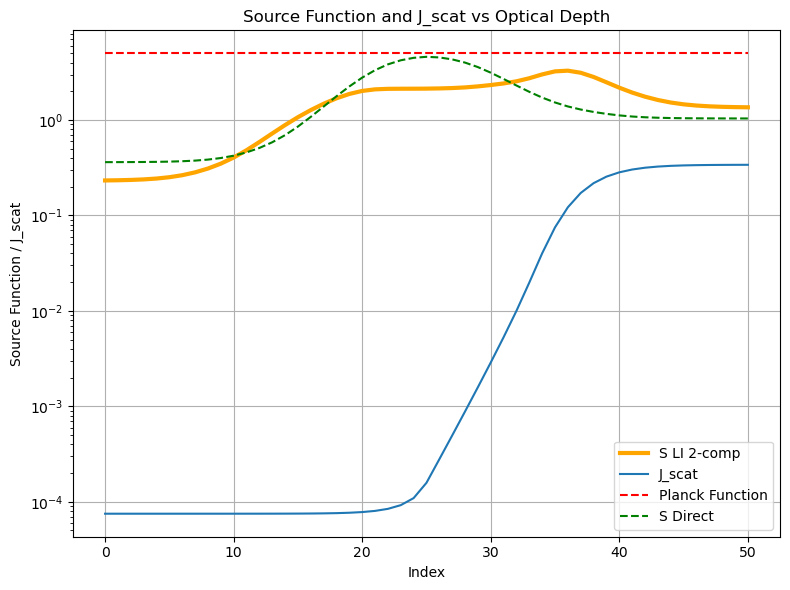

In [12]:
 # Other variant where we use the depth index to plot all the variables
plt.figure(figsize=(8,6))
plt.semilogy(S_LI, linestyle = "-", linewidth = 3, color = "orange", label="S LI 2-comp")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
# plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

<h2>28. 01. 2026.</h2>
<p> The approach showed above needs refinement. </p>

In [13]:
slab3 = ill.Slab(ND, tau_max, epsilon, B, H=10e6) # Note height in m

# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab3.a = 0.1 # Set damping parameter
spectrum = slab3.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab3.calculate_J_scat()

slab3.composite_source()
S_composite = slab3.S

TypeError: Slab.Line.__init__() got an unexpected keyword argument 'd_lamb'

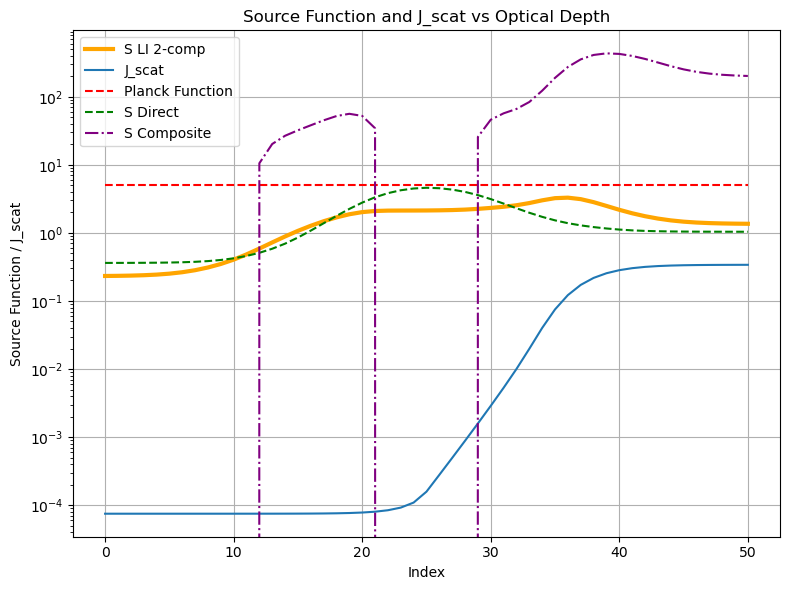

In [ ]:
plt.figure(figsize=(8,6))
plt.semilogy(S_LI, linestyle = "-", linewidth = 3, color = "orange", label="S LI 2-comp")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
plt.semilogy(S_composite, linestyle = "-.", color = "purple", alpha = 1.0, label="S Composite")
# plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

[-123.28239429 -122.11154096 -120.17490317 -117.01593893 -111.98337515
 -104.26530432  -93.10768012  -78.29512787  -60.60511651  -41.44677716
  -21.98755842   -3.83730455   10.53390355   20.21828589   26.7079651
   32.15049664   38.07782172   45.01123802   52.02921505   56.16135521
   52.27045765   34.49287932   -0.58271495  -49.24109782  -95.41259817
 -113.90672329  -93.96951719  -51.76141992   -7.69317766   25.66359818
   45.96023947   57.04711393   66.15778866   83.69962954  122.65601109
  189.37391919  273.55322064  353.9708589   410.91625204  433.83916821
  425.64342273  397.62732796  359.38247532  318.32393399  281.33676347
  252.44508252  232.07917609  218.66313689  210.19351622  204.98412002
  201.82854234]


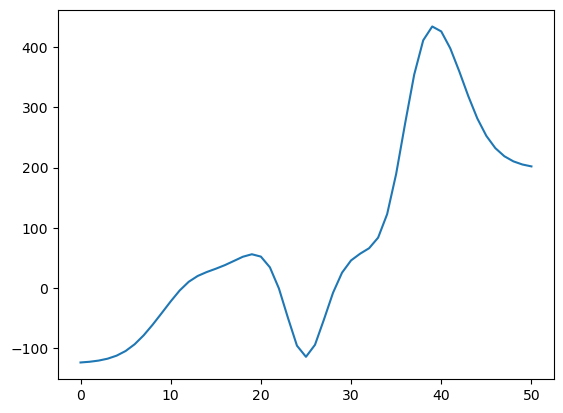

In [ ]:
print(S_composite)
plt.plot(S_composite)

<h2>19. 02. 2026.</h2>
<p>A short presentation of some new results.</p>

In [14]:
import SLab_linev2 as v2

# Create a slab
# Define the input parameters
ND = 81
tau_max = 1e3
epsilon = np.ones(ND) * 5e-3
B = np.ones(ND) * 5.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab = v2.Slab(ND, tau_max, epsilon, B, H)

# And lines
line1 = v2.Slab.Line(81, line_center=0.0, a=0.1, k=1.0, r=0.0, slab_in=slab)  # Example line, we will need to pass the slab instance to the line   
line2 = v2.Slab.Line(81, line_center=3.2, a=0.2, k=8.0, r=0.0, slab_in=slab)  # Another example line
line3 = v2.Slab.Line(81, line_center=8.5, a= 0.5, k=3.0, r=0.0, slab_in=slab)

In [15]:
# Create a list of lines and pass it to the slab
lines = [line1, line2, line3]

# Now we can calculate the source function for each line
slab.global_x_grid(lines)
line1.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)
line2.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)
line3.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)

  6%|▌         | 56/1000 [00:01<00:19, 47.66it/s]


Convergence achieved after 56 iterations with max dS = 9.26e-07


  5%|▌         | 50/1000 [00:01<00:19, 49.59it/s]


Convergence achieved after 50 iterations with max dS = 8.50e-07


  5%|▌         | 50/1000 [00:00<00:18, 50.44it/s]

Convergence achieved after 50 iterations with max dS = 8.22e-07


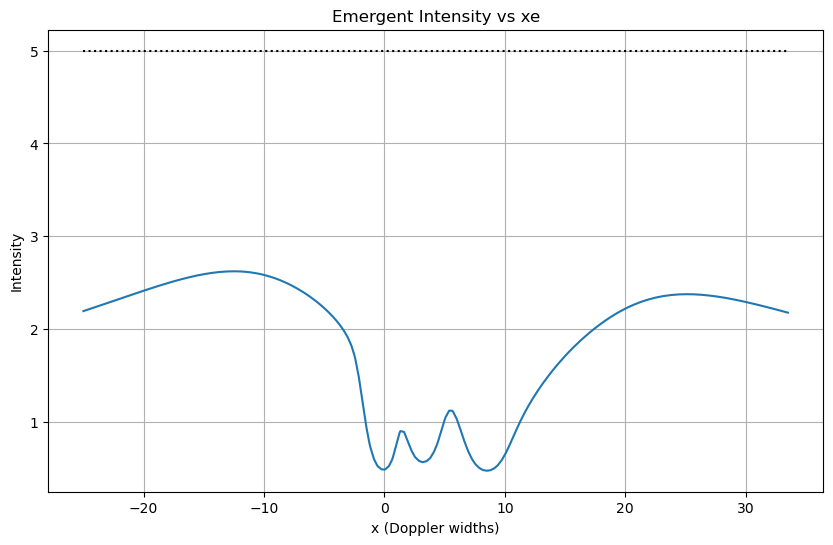

In [16]:
 # Compute the source function for each line
S = slab.formal_solution(lines, mu = 1.0, boundary_condition = 1.0)
# Plot the intensity
plt.figure(figsize=(10, 6))
plt.plot(slab.x_values, S, label='Intensity')
# Plot Planck function B (use mean if B is depth-dependent) as reference
plt.plot(slab.x_values, np.mean(slab.B) * np.ones_like(slab.x_values), ':k', label='Planck B')
plt.xlabel('x (Doppler widths)')
plt.ylabel('Intensity')
plt.title('Emergent Intensity vs xe')
plt.grid()
plt.savefig('intensity_vs_x_k1_'+str(line1.k)+'_k2_'+str(line2.k)+'.png')

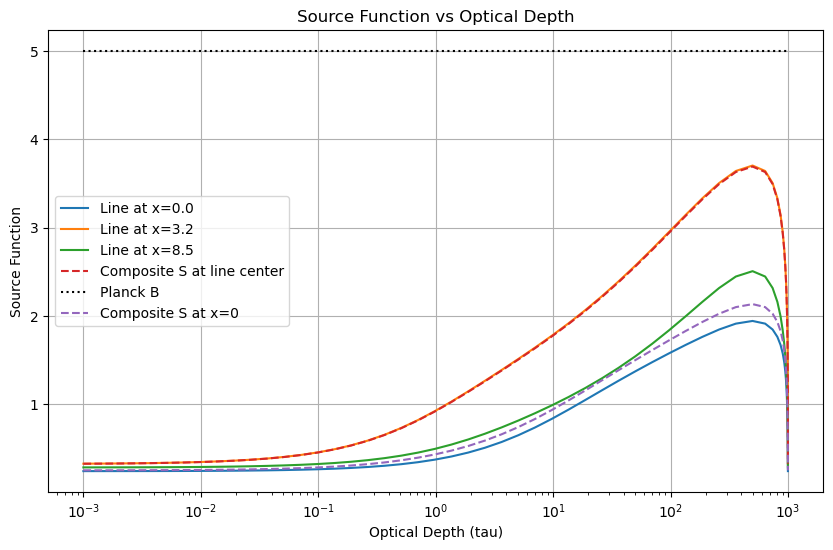

In [17]:
 # Plot the source function of each line and composite source function
plt.figure(figsize=(10, 6))
for line in lines:
    if hasattr(line, "S_line"):
        plt.plot(slab.tau, line.S_line, label=f'Line at x={line.line_center}')
composite_S = slab.composite_S(lines)
plt.plot(slab.tau, composite_S[:, slab.x_values.size//2], label='Composite S at line center', linestyle='--')
plt.plot(slab.tau, slab.B, ':k', label = 'Planck B')
center_idx = np.argmin(np.abs(slab.x_values - 0.0))
plt.plot(slab.tau, composite_S[:, center_idx], label='Composite S at x=0', linestyle='--')
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Source Function')
plt.title('Source Function vs Optical Depth')
plt.xscale('log')
plt.grid()
plt.legend()
plt.savefig('source_function_vs_tau_k1_'+str(line1.k)+'_k2_'+str(line2.k)+'.png')

In [18]:
 # Build composite source function grid (depth x frequency)
S_nu_grid = slab.composite_S(lines)   # shape (ND, Nfreq)

# Compute emergent intensity (formal solution) and store in slab.I
I_emergent = slab.formal_solution(lines, mu = 1.0, boundary_condition = 1.0)

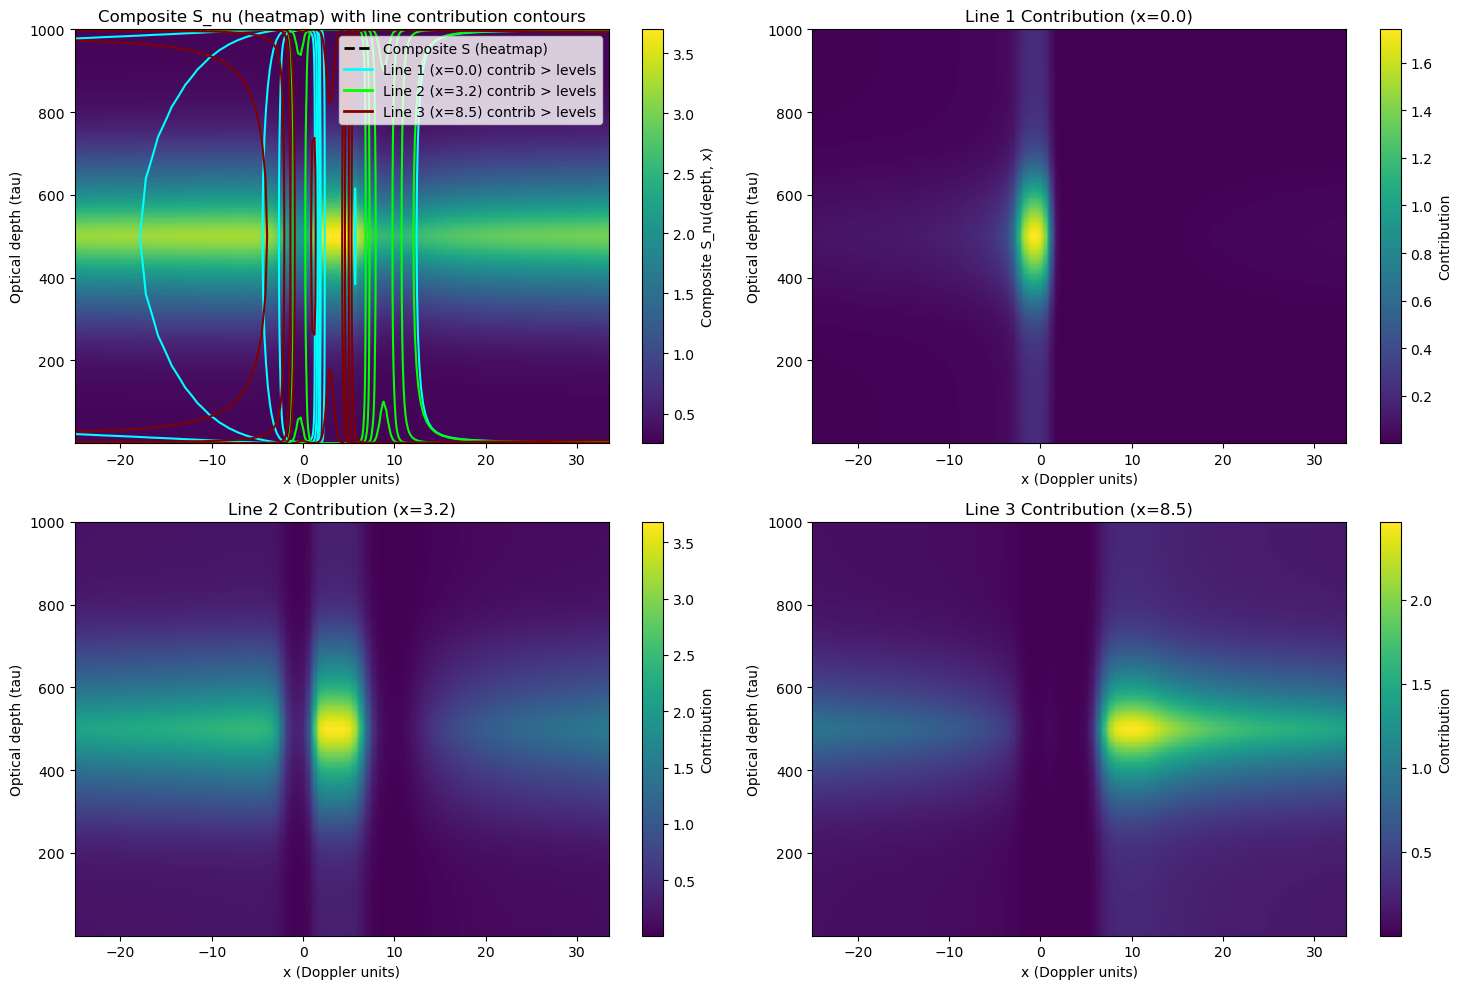

In [19]:
# Combined plot: Composite S_nu heatmap with contours + subplots for each line's contribution
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x = slab.x_values
tau = slab.tau
B = slab.B

# Ensure per-line normalized profile present
for line in lines:
    if not hasattr(line, 'phi_x_global'):
        # Compute if missing
        line.compute_phi_x(slab.x_values)
        if hasattr(slab, 'x_weights') and slab.x_weights.size == slab.x_values.size:
            norm = np.sum(line.phi_x * slab.x_weights)
            if norm != 0.0:
                line.phi_x_global = line.phi_x / norm
            else:
                line.phi_x_global = line.phi_x
        else:
            line.phi_x_global = line.phi_x

# Precompute denom used in composite S
denom = np.zeros_like(x)
for line in lines:
    denom += line.k * line.phi_x_global
denom_safe = np.where(denom == 0.0, 1.0, denom)

# Build per-line contribution arrays (depth x frequency)
contribs = []
for line in lines:
    contrib = np.zeros_like(S_nu_grid)
    for d in range(slab.ND):
        contrib[d, :] = (line.k * line.phi_x_global * line.S_line[d]) / denom_safe
    contribs.append(contrib)

# Create figure with subplots: 2x2 grid
fig = plt.figure(figsize=(15, 10))

# Main plot: composite S heatmap with contours (top-left, spanning if needed)
ax_main = plt.subplot(2, 2, 1)
im = ax_main.imshow(S_nu_grid, aspect='auto', origin='lower',
                    extent=[x[0], x[-1], tau[0], tau[-1]], cmap='viridis')
cbar = plt.colorbar(im, ax=ax_main, label='Composite S_nu(depth, x)')
# Choose distinct contour colors for lines
palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
contour_levels = [0.01, 0.05, 0.1, 0.25, 0.5]  # Fractional contribution levels

# Build explicit legend handles
legend_handles = []
for idx, contrib in enumerate(contribs):
    color = palette[idx % len(palette)]
    cs = ax_main.contour(x, tau, contrib, levels=contour_levels, colors=color, linewidths=1.5)
    # Create a proxy line for legend
    legend_handles.append(Line2D([0], [0], color=color, lw=2, label=f'Line {idx+1} (x={lines[idx].line_center}) contrib > levels'))

ax_main.set_xlabel('x (Doppler units)')
ax_main.set_ylabel('Optical depth (tau)')
ax_main.set_title('Composite S_nu (heatmap) with line contribution contours')
# Add legend
heatmap_proxy = Line2D([0], [0], color='k', lw=2, linestyle='--', label='Composite S (heatmap)')
all_handles = [heatmap_proxy] + legend_handles
ax_main.legend(handles=all_handles, loc='upper right')

# Subplots for each line's contribution (bottom row)
for idx in range(len(contribs)):
    ax = plt.subplot(2, 2, idx + 2)  # 2,3,4
    im = ax.imshow(contribs[idx], aspect='auto', origin='lower', extent=[x[0], x[-1], tau[0], tau[-1]], cmap='viridis')
    ax.set_title(f'Line {idx+1} Contribution (x={lines[idx].line_center})')
    ax.set_xlabel('x (Doppler units)')
    ax.set_ylabel('Optical depth (tau)')
    plt.colorbar(im, ax=ax, label='Contribution')

plt.tight_layout()
plt.show()

In [20]:
plot_line_and_composite(lines, slab, S_nu_grid, I_emergent)

Saved plots: per-line emissivity, S_vs_tau, composite S vs x/tau, combined contribution heatmap, and per-line contributions (all depths).


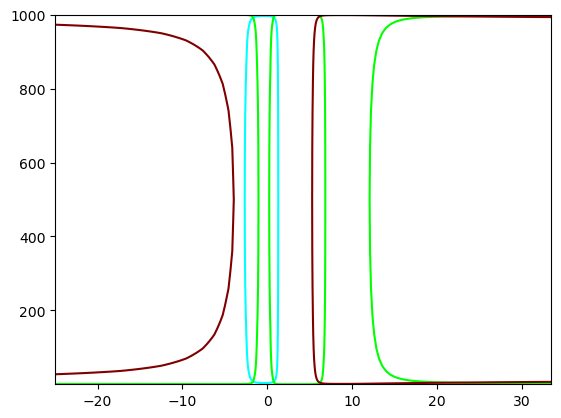

In [23]:
# Interactive 3D Surface Plot of Composite S_nu with Contours for Line Contributions
# Uses Plotly for rotation and contours on the surface to highlight contributions.
# Note: Install plotly if not present (pip install plotly).

import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt  # Needed for contour extraction

# Assuming S_nu_grid, x, tau, contribs are defined from previous cells
# If not, uncomment and run setup:
# x = slab.x_values
# tau = slab.tau
# S_nu_grid = slab.composite_S(lines)
# # And contribs as before

# Create meshgrid
X, T = np.meshgrid(x, tau)

# Create the 3D surface plot
fig = go.Figure()

# Add the main surface
fig.add_trace(go.Surface(
    x=X, y=T, z=S_nu_grid,
    colorscale='Viridis',
    name='Composite S_nu',
    showscale=True,
    colorbar=dict(title='Composite S_nu')
))

# Add contours for each line's contribution on the surface
# We'll project the contours by adding them as lines on the surface
palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
for idx, contrib in enumerate(contribs):
    # Add contour lines at a specific level (e.g., 0.1) projected on the surface
    levels = [0.5]  # Adjust levels as needed
    cs = plt.contour(X, T, contrib, levels=levels, colors=palette[idx % len(palette)])
    # Extract paths from contour
    for level_idx, segs in enumerate(cs.allsegs):
        for path in segs:
            verts = path  # path is already a numpy array of shape (n, 2)
            x_verts = verts[:, 0]
            y_verts = verts[:, 1]
            # Interpolate z from S_nu_grid at these points (approximate using mid-depth)
            z_interp = np.interp(x_verts, x, S_nu_grid[len(tau)//2, :])
            fig.add_trace(go.Scatter3d(
                x=x_verts, y=y_verts, z=z_interp,
                mode='lines',
                line=dict(color=palette[idx % len(palette)], width=4),
                name=f'Line {idx+1} Contrib > {levels[level_idx]}',
                showlegend=True
            ))

# Update layout for better viewing
fig.update_layout(
    title='Interactive 3D Surface of Composite S_nu with Line Contribution Contours',
    scene=dict(
        xaxis_title='x (Doppler units)',
        yaxis_title='Optical Depth (tau)',
        zaxis_title='Source Function S_nu',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))  # Initial view
    ),
    width=800, height=600
)

# Show the interactive plot
fig.show()